# Mamba vs Transformer SAE Analysis
state vs delta; Mamba-1.4B (layers 12/24/36) and Pythia-1.4B (layers 6/12/18)

`/raid/sasaki/runs` にある抽出済み・学習済み SAE を総合解析するノート。章立ては:
1. Setup & Data loading / sanity
2. Activations & SAE recon/sparsity (基本統計)
3. Feature-wise stats (dead units, norms)
4. Token/context alignment (concept analysis)
5. Dictionary geometry & cross-condition alignment
6. Cross-layer/model/signal summary
7. Causal eval: ablation & steering (雛形)
8. Robustness checks (雛形)


In [1]:

import sys, os, json, glob, math
from pathlib import Path
from typing import Optional, List, Tuple

import torch
import pandas as pd
import matplotlib.pyplot as plt

# プロジェクトルートをモジュールパスに追加
sys.path.append('/workspace')  # コンテナ内

RUN_ROOT = Path('/raid/sasaki/runs')
MODELS = {
    'mamba': {
        'root': RUN_ROOT / 'mamba_1.4b_hf',
        'layers': [4, 12, 24, 36, 44],
        'signals': ['state', 'delta'],
    },
    'pythia': {
        'root': RUN_ROOT / 'pythia_1.4b_deduped',
        'layers': [2, 6, 12, 18, 24],
        'signals': ['state', 'delta'],
    },
}

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# ---------------- helpers ----------------

def paths(model_key: str, layer: int, signal: str) -> Path:
    return MODELS[model_key]['root'] / f'layer_{layer}' / signal


def load_meta(model_key: str, layer: int, signal: str):
    path = paths(model_key, layer, signal) / 'meta.json'
    with open(path) as f:
        return json.load(f)


def load_ckpt(model_key: str, layer: int, signal: str, map_location=None):
    path = paths(model_key, layer, signal) / 'sae_checkpoint.pt'
    return torch.load(path, map_location=map_location or device)


def load_sae(model_key: str, layer: int, signal: str):
    from sae_model import SAE
    ckpt = load_ckpt(model_key, layer, signal)
    sae = SAE(
        input_dim=ckpt['input_dim'],
        hidden_dim=ckpt['hidden_dim'],
        mode=ckpt['mode'],
        l1_lambda=ckpt.get('l1_lambda'),
        k_frac=ckpt.get('k_frac', 0.1),
    ).to(device)
    sae.load_state_dict(ckpt['state_dict'])
    sae.eval()
    return sae, ckpt


def iter_chunks(model_key: str, layer: int, signal: str, max_chunks: Optional[int]=None, map_location=None):
    pat = paths(model_key, layer, signal) / 'chunk_*.pt'
    for i, p in enumerate(sorted(glob.glob(str(pat)))):
        if max_chunks is not None and i >= max_chunks:
            break
        yield i, Path(p), torch.load(p, map_location=map_location or device)


device: cuda:0


## 1. Setup / sanity check
- meta / ckpt / log / chunk の存在確認
- メタ情報（サンプル数・次元など）をざっと見る

In [2]:

rows = []
for model_key, cfg in MODELS.items():
    for layer in cfg['layers']:
        for signal in cfg['signals']:
            root = paths(model_key, layer, signal)
            meta_path = root / 'meta.json'
            meta = json.load(open(meta_path)) if meta_path.exists() else {}
            rows.append({
                'model': model_key,
                'layer': layer,
                'signal': signal,
                'meta': meta_path.exists(),
                'ckpt': (root / 'sae_checkpoint.pt').exists(),
                'log': (root / 'train_log.jsonl').exists(),
                'chunks': len(list(root.glob('chunk_*.pt'))),
                'total_tokens': meta.get('total_samples'),
                'd_model': meta.get('d_model'),
            })

df_exists = pd.DataFrame(rows)
df_exists

,model,layer,signal,meta,ckpt,log,chunks,total_tokens,d_model
0,mamba,12,state,True,True,True,50,5000004,2048
1,mamba,12,delta,True,True,True,50,5000004,2048
2,mamba,24,state,True,True,True,50,5000004,2048
3,mamba,24,delta,True,True,True,50,5000004,2048
4,mamba,36,state,True,True,True,50,5000004,2048
5,mamba,36,delta,True,True,True,50,5000004,2048
6,pythia,6,state,True,True,True,50,5000004,2048
7,pythia,6,delta,True,True,True,50,5000004,2048
8,pythia,12,state,True,True,True,50,5000004,2048
9,pythia,12,delta,True,True,True,50,5000004,2048


## 2. Activations & SAE recon / sparsity (train_log)
- 最終 loss / recon_loss / global_sparsity
- sparsity 推移

,model,layer,signal,loss,recon_loss,reg_loss,global_sparsity
2694,pythia,18,state,0.027932,0.027932,0.0,0.114134
2939,pythia,18,delta,0.081473,0.081473,0.0,0.181984
2449,pythia,12,delta,0.107924,0.107924,0.0,0.164973
2204,pythia,12,state,0.022034,0.022034,0.0,0.117608
1224,mamba,36,state,0.007828,0.007828,0.0,0.122561
1469,mamba,36,delta,0.058095,0.058095,0.0,0.215862
1959,pythia,6,delta,0.048453,0.048453,0.0,0.140721
1714,pythia,6,state,0.016050,0.016050,0.0,0.119357
734,mamba,24,state,0.014701,0.014701,0.0,0.120091
979,mamba,24,delta,0.009171,0.009171,0.0,0.126026


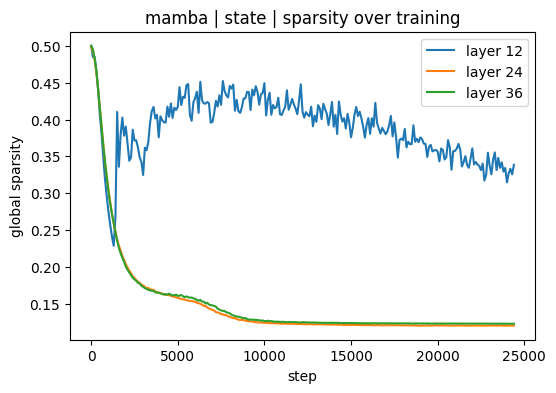

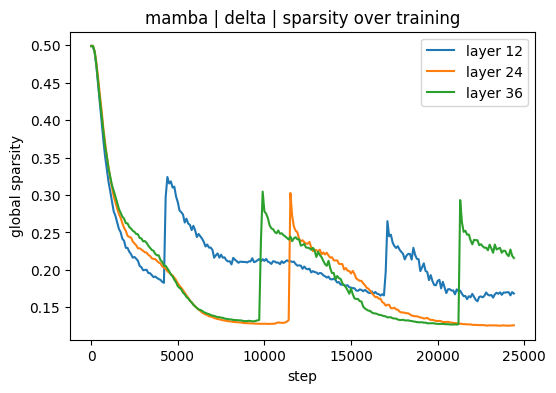

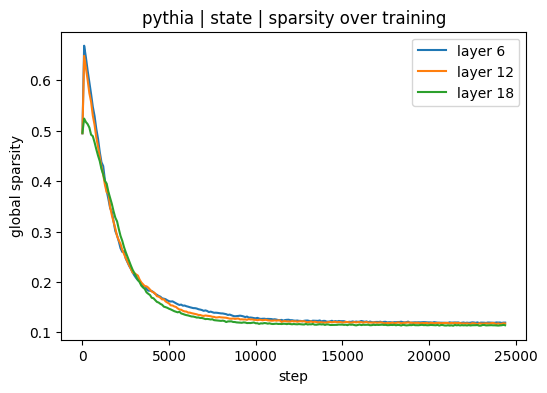

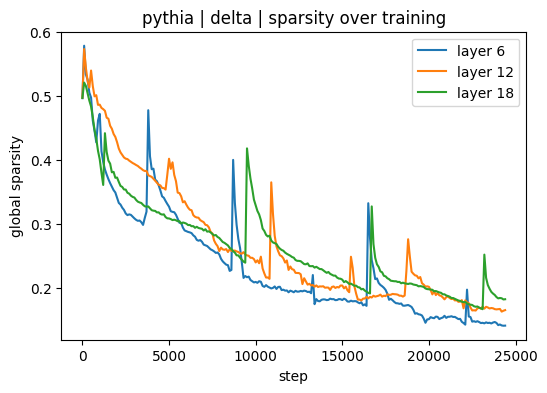

In [3]:

def load_train_logs(model_key: str):
    rows = []
    cfg = MODELS[model_key]
    for layer in cfg['layers']:
        for signal in cfg['signals']:
            log_path = paths(model_key, layer, signal) / 'train_log.jsonl'
            if not log_path.exists():
                continue
            with open(log_path) as f:
                for line in f:
                    rec = json.loads(line)
                    rec['model'] = model_key
                    rec['layer'] = layer
                    rec['signal'] = signal
                    rows.append(rec)
    return pd.DataFrame(rows)

df_log = pd.concat([load_train_logs('mamba'), load_train_logs('pythia')], ignore_index=True)

last = df_log.sort_values('step').groupby(['model','layer','signal']).tail(1)
display(last[['model','layer','signal','loss','recon_loss','reg_loss','global_sparsity']])

for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        plt.figure(figsize=(6,4))
        for layer in MODELS[model_key]['layers']:
            d = df_log[(df_log.model==model_key) & (df_log.signal==signal) & (df_log.layer==layer)]
            if len(d)==0: continue
            plt.plot(d['step'], d['global_sparsity'], label=f'layer {layer}')
        plt.title(f'{model_key} | {signal} | sparsity over training')
        plt.xlabel('step'); plt.ylabel('global sparsity'); plt.legend(); plt.show()


## 3. Feature-wise stats & dead units
- 発火頻度 p_i, 条件付き平均 |z|
- dead / nearly-dead feature 率
- decoder/encoder ノルム分布

In [4]:

from collections import defaultdict

def compute_feature_stats(model_key: str, layer: int, signal: str, max_chunks=3):
    sae, ckpt = load_sae(model_key, layer, signal)
    nonzero = None; sum_abs = None; total = 0
    for _, _, x in iter_chunks(model_key, layer, signal, max_chunks=max_chunks):
        x = x.to(device)
        with torch.no_grad():
            x_hat, z = sae(x)
        z = z.detach().cpu()
        if nonzero is None:
            nonzero = (z!=0).sum(dim=0)
            sum_abs = z.abs().sum(dim=0)
        else:
            nonzero += (z!=0).sum(dim=0)
            sum_abs += z.abs().sum(dim=0)
        total += z.shape[0]
    freq = nonzero.float() / total
    mean_abs = sum_abs / nonzero.clamp(min=1)
    return freq, mean_abs

stats = {}
for model_key in MODELS:
    for layer in MODELS[model_key]['layers']:
        for signal in MODELS[model_key]['signals']:
            freq, mean_abs = compute_feature_stats(model_key, layer, signal, max_chunks=3)
            stats[(model_key, layer, signal)] = (freq, mean_abs)
            dead_ratio = (freq < 1e-4).float().mean()
            print(model_key, layer, signal, 'mean freq', float(freq.mean()), 'dead<1e-4', float(dead_ratio))


/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)
/tmp/ipykernel_45974/354457

mamba 12 state mean freq 0.0007742359302937984 dead<1e-4 0.9154052734375
mamba 12 delta mean freq 0.005769291426986456 dead<1e-4 0.52911376953125
mamba 24 state mean freq 0.09850795567035675 dead<1e-4 0.794921875
mamba 24 delta mean freq 0.09996466338634491 dead<1e-4 0.73785400390625
mamba 36 state mean freq 0.0999755859375 dead<1e-4 0.75439453125
mamba 36 delta mean freq 0.09997427463531494 dead<1e-4 0.0028076171875
pythia 6 state mean freq 0.09879013150930405 dead<1e-4 0.35418701171875
pythia 6 delta mean freq 0.09292533993721008 dead<1e-4 0.02996826171875
pythia 12 state mean freq 0.09828850626945496 dead<1e-4 0.32421875
pythia 12 delta mean freq 0.0897892564535141 dead<1e-4 0.00042724609375
pythia 18 state mean freq 0.09997550398111343 dead<1e-4 0.2469482421875
pythia 18 delta mean freq 0.09986327588558197 dead<1e-4 0.00018310546875


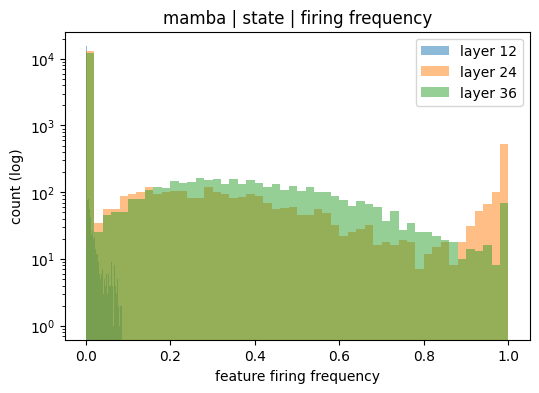

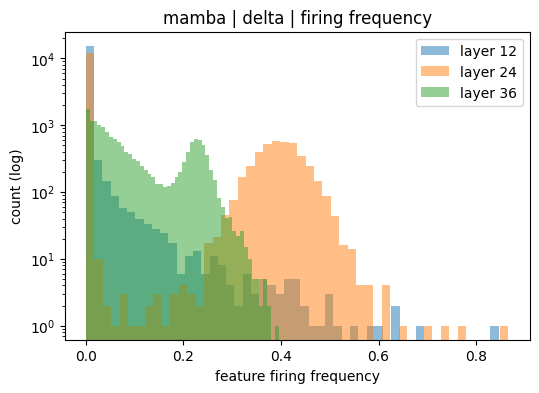

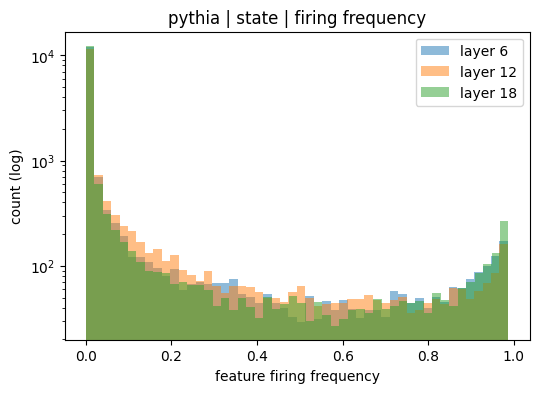

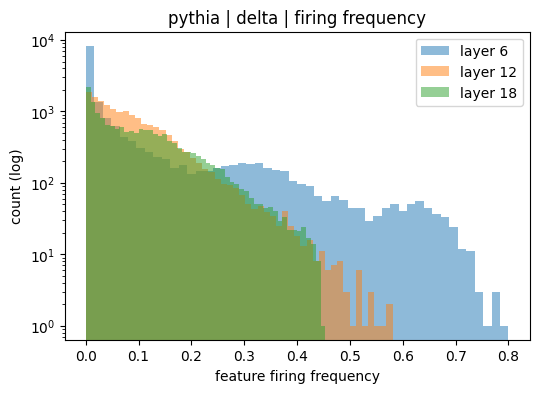

In [5]:

# 発火頻度ヒストグラム
for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        plt.figure(figsize=(6,4))
        for layer in MODELS[model_key]['layers']:
            freq, _ = stats[(model_key, layer, signal)]
            plt.hist(freq.numpy(), bins=50, alpha=0.5, label=f'layer {layer}')
        plt.yscale('log')
        plt.xlabel('feature firing frequency'); plt.ylabel('count (log)')
        plt.title(f'{model_key} | {signal} | firing frequency')
        plt.legend(); plt.show()

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


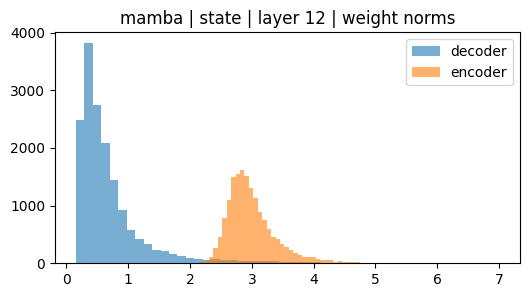

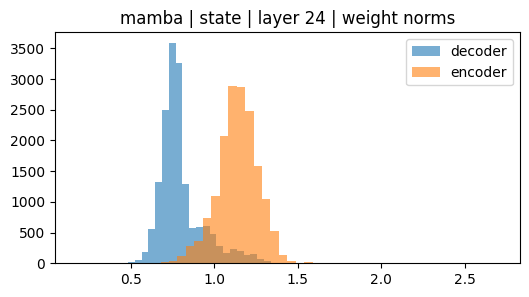

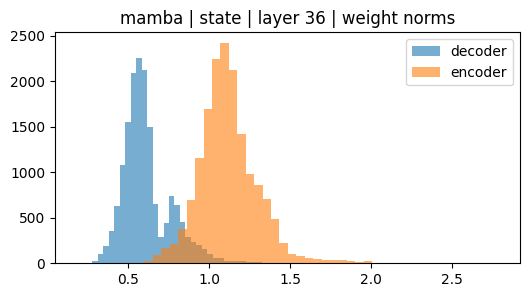

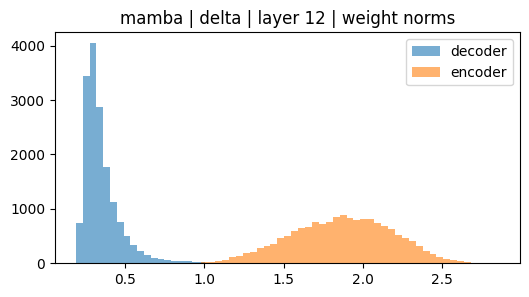

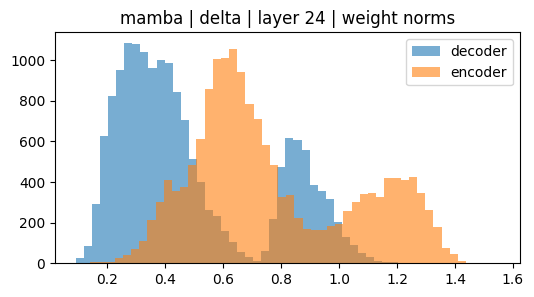

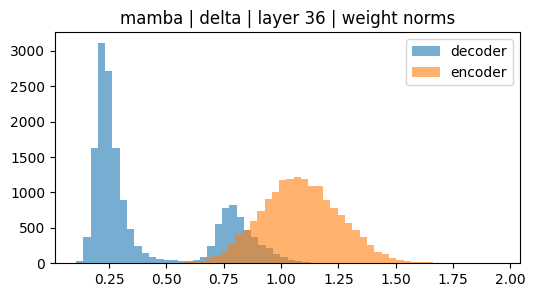

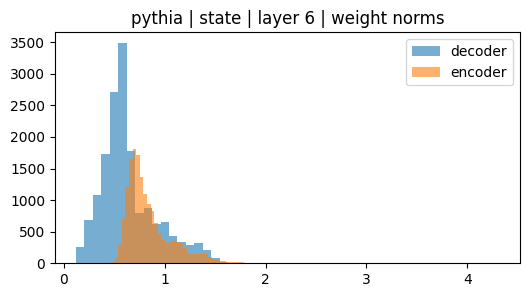

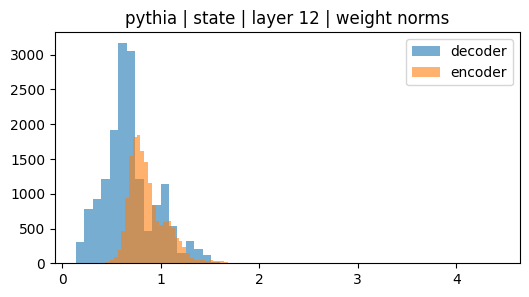

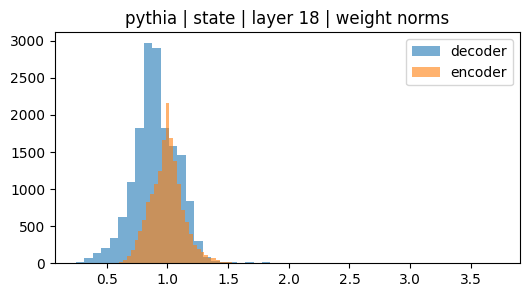

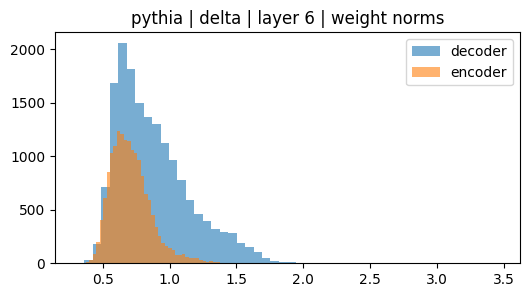

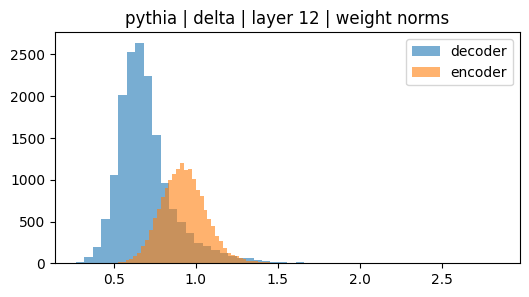

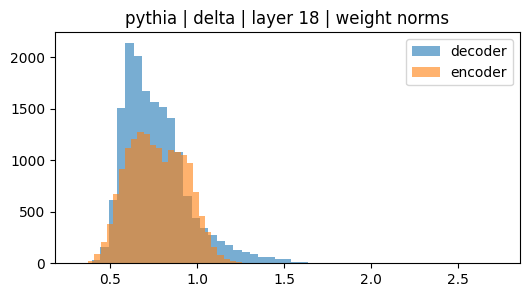

In [6]:

# decoder/encoder 列ノルム分布
for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        for layer in MODELS[model_key]['layers']:
            sae, _ = load_sae(model_key, layer, signal)
            dec_norm = sae.decoder.weight.norm(dim=0).detach().cpu()
            enc_norm = sae.encoder.weight.norm(dim=1).detach().cpu()
            plt.figure(figsize=(6,3))
            plt.hist(dec_norm.numpy(), bins=50, alpha=0.6, label='decoder')
            plt.hist(enc_norm.numpy(), bins=50, alpha=0.6, label='encoder')
            plt.title(f'{model_key} | {signal} | layer {layer} | weight norms')
            plt.legend(); plt.show()


## 4. Reconstruction vs Sparsity (sample-wise)
- k(x)=活性ユニット数 と再構成誤差の散布図
- k(x) 分布（箱ひげなど）

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)
/tmp/ipykernel_45974/354457

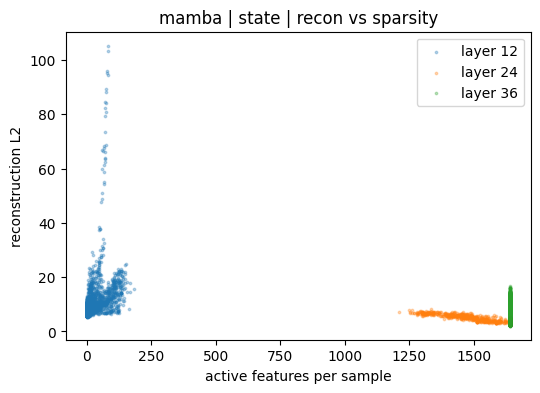

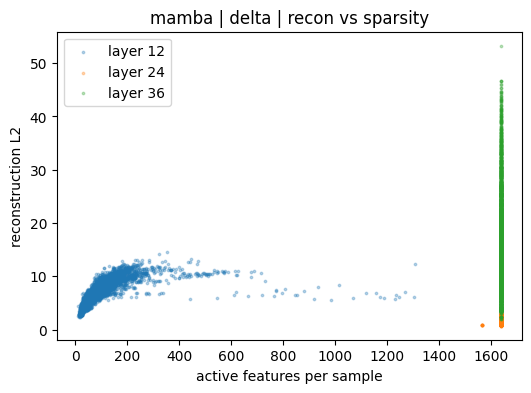

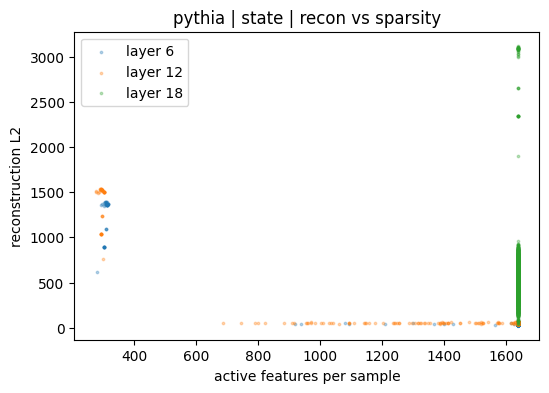

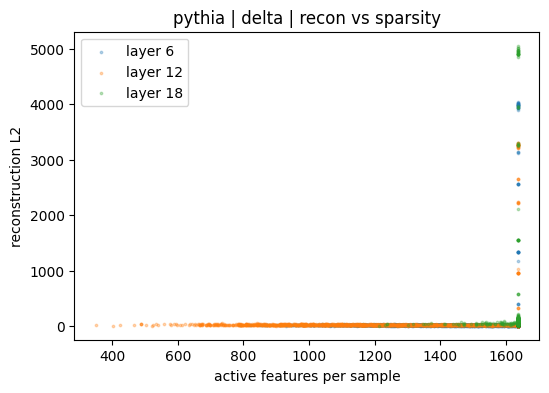

In [7]:

import random

def sample_recon_stats(model_key: str, layer: int, signal: str, max_chunks=1, max_samples=5000):
    sae, ckpt = load_sae(model_key, layer, signal)
    errs = []; ks = []
    taken = 0
    for _, _, x in iter_chunks(model_key, layer, signal, max_chunks=max_chunks):
        x = x.to(device)
        with torch.no_grad():
            x_hat, z = sae(x)
        err = ((x - x_hat)**2).sum(dim=1).sqrt().cpu()
        k = (z!=0).sum(dim=1).cpu()
        errs.append(err); ks.append(k)
        taken += x.shape[0]
        if taken >= max_samples:
            break
    err = torch.cat(errs)[:max_samples]
    k = torch.cat(ks)[:max_samples]
    return err, k

for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        plt.figure(figsize=(6,4))
        for layer in MODELS[model_key]['layers']:
            err, k = sample_recon_stats(model_key, layer, signal, max_chunks=1, max_samples=4000)
            plt.scatter(k.numpy(), err.numpy(), s=3, alpha=0.3, label=f'layer {layer}')
        plt.xlabel('active features per sample'); plt.ylabel('reconstruction L2')
        plt.title(f'{model_key} | {signal} | recon vs sparsity')
        plt.legend(); plt.show()


## 5. Dictionary geometry
- decoder コヒーレンス（|cos| 分布）
- PCA との比較のための雛形
- 辞書アラインメント (state/delta, model間, layer間)

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


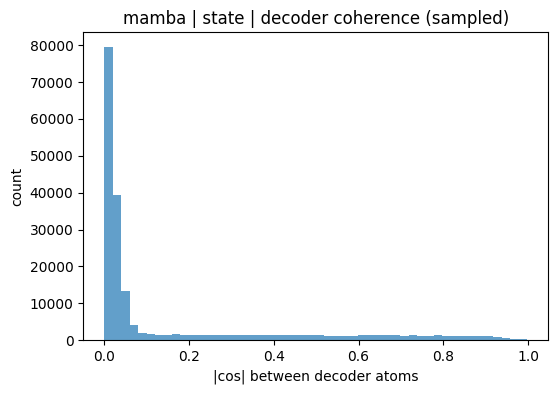

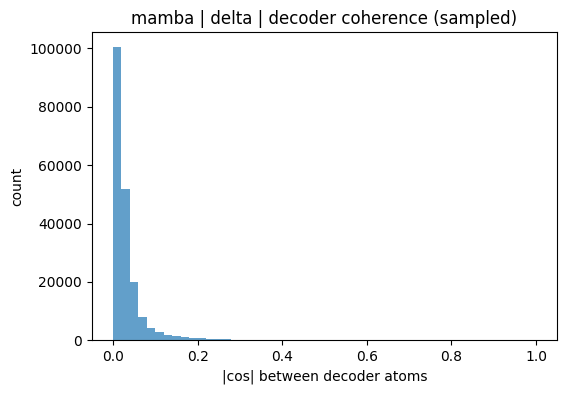

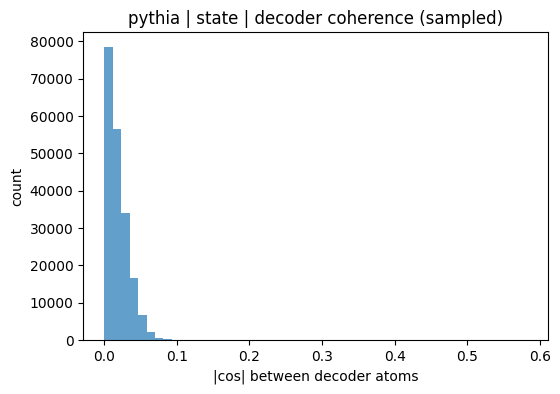

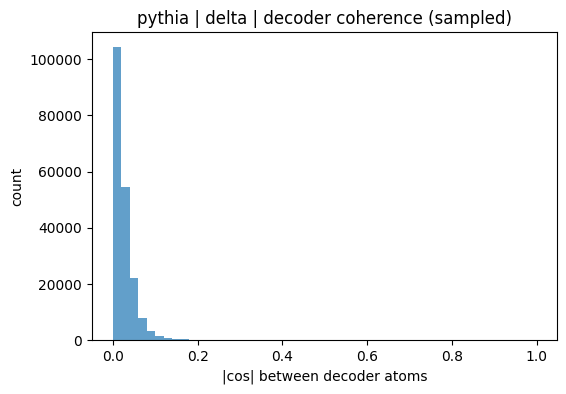

In [8]:

import numpy as np

def decoder_matrix(model_key, layer, signal):
    sae, _ = load_sae(model_key, layer, signal)
    W = sae.decoder.weight.detach().cpu()  # [d_out, d_in]
    return W.T  # [m, d]

# コヒーレンス分布
for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        plt.figure(figsize=(6,4))
        all_sims = []
        for layer in MODELS[model_key]['layers']:
            W = decoder_matrix(model_key, layer, signal)
            idx = torch.randperm(W.shape[0])[:256]
            V = W[idx]
            Vn = V / V.norm(dim=1, keepdim=True)
            sims = (Vn @ Vn.T).abs()
            mask = ~torch.eye(sims.shape[0], dtype=bool)
            all_sims.append(sims[mask])
        sims_cat = torch.cat(all_sims)
        plt.hist(sims_cat.numpy(), bins=50, alpha=0.7)
        plt.xlabel('|cos| between decoder atoms'); plt.ylabel('count')
        plt.title(f'{model_key} | {signal} | decoder coherence (sampled)')
        plt.show()


In [9]:

# state vs delta 辞書アラインメント (同層)
for model_key in MODELS:
    for layer in MODELS[model_key]['layers']:
        W_s = decoder_matrix(model_key, layer, 'state')
        W_d = decoder_matrix(model_key, layer, 'delta')
        W_s_n = W_s / W_s.norm(dim=1, keepdim=True)
        W_d_n = W_d / W_d.norm(dim=1, keepdim=True)
        sims = W_s_n @ W_d_n.T
        max_s = sims.max(dim=1).values
        max_d = sims.max(dim=0).values
        print(f'{model_key} layer {layer}: state->delta mean max {float(max_s.mean()):.3f}, delta->state {float(max_d.mean()):.3f}')


/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


mamba layer 12: state->delta mean max 0.107, delta->state 0.092
mamba layer 24: state->delta mean max 0.113, delta->state 0.111
mamba layer 36: state->delta mean max 0.132, delta->state 0.128
pythia layer 6: state->delta mean max 0.118, delta->state 0.109
pythia layer 12: state->delta mean max 0.118, delta->state 0.112
pythia layer 18: state->delta mean max 0.115, delta->state 0.114


### PCA との比較（雛形）
生表現 `x` の PCA を計算し、辞書列を射影して説明分散を見る。計算コストが大きい場合はサンプルと次元を絞ってください。

In [10]:

from sklearn.decomposition import PCA
def pca_coverage(model_key, layer, signal, n_components=256, max_chunks=1):
    xs = []
    for _, _, x in iter_chunks(model_key, layer, signal, max_chunks=max_chunks, map_location='cpu'):
        xs.append(x)
    X = torch.cat(xs).numpy()
    pca = PCA(n_components=n_components).fit(X)
    W = decoder_matrix(model_key, layer, signal).numpy()
    proj = W @ pca.components_.T
    var_expl = (proj**2).sum(axis=1)
    return pca.explained_variance_ratio_.sum(), var_expl.mean()

rows = []
for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        for layer in MODELS[model_key]['layers']:
            total_var, mean_proj = pca_coverage(
                model_key, layer, signal,
                n_components=256, max_chunks=1
            )
            rows.append({
                "model": model_key,
                "layer": layer,
                "signal": signal,
                "pca_var_256": total_var,
                "mean_proj_power": mean_proj,
            })

df_pca = pd.DataFrame(rows).sort_values(["model", "signal", "layer"])
display(df_pca)




/tmp/ipykernel_45974/3544576655.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  yield i, Path(p), torch.load(p, map_location=map_location or device)
/tmp/ipykernel_4597

,model,layer,signal,pca_var_256,mean_proj_power
3,mamba,12,delta,0.453033,0.026431
4,mamba,24,delta,0.484427,0.059233
5,mamba,36,delta,0.568858,0.048545
0,mamba,12,state,0.473659,0.129592
1,mamba,24,state,0.488486,0.106330
2,mamba,36,state,0.592448,0.084313
9,pythia,6,delta,0.959196,0.144881
10,pythia,12,delta,0.962730,0.105559
11,pythia,18,delta,0.924769,0.106593
6,pythia,6,state,0.978760,0.084843


## 6. Cross-layer / cross-model / cross-signal summary
- これまでの指標を表やマルチパネルでまとめる（必要に応じて埋めてください）。

In [11]:

# 例: mean firing freq を一覧表示
rows = []
for k, v in stats.items():
    model_key, layer, signal = k
    freq, mean_abs = v
    rows.append({
        'model': model_key,
        'layer': layer,
        'signal': signal,
        'mean_freq': float(freq.mean()),
        'mean_amp_cond': float(mean_abs.mean()),
        'dead_ratio_<1e-4': float((freq<1e-4).float().mean()),
    })
summary = pd.DataFrame(rows)
display(summary)


,model,layer,signal,mean_freq,mean_amp_cond,dead_ratio_<1e-4
0,mamba,12,state,0.000774,0.083736,0.915405
1,mamba,12,delta,0.005769,0.181077,0.529114
2,mamba,24,state,0.098508,0.113314,0.794922
3,mamba,24,delta,0.099965,0.109374,0.737854
4,mamba,36,state,0.099976,0.304746,0.754395
5,mamba,36,delta,0.099974,1.756837,0.002808
6,pythia,6,state,0.098790,1.086868,0.354187
7,pythia,6,delta,0.092925,4.081436,0.029968
8,pythia,12,state,0.098289,0.840220,0.324219
9,pythia,12,delta,0.089789,2.531727,0.000427


## 7. Causal evaluation (ablation / steering)
- forward hook で SAE を挟み、指定 feature を 0 / スケール。
- CE/perplexity や特定トークン logit の変化を測定。
- 実験内容に合わせてこのセルにコードを追加してください。

In [ ]:

# ここに ablation / steering 実験コードを追記するスペース


## 8. Robustness checks
- chunk サブサンプリングで統計のばらつきを確認
- 複数シードで学習した SAE があれば、辞書アラインメントと指標の再現性をチェック


In [ ]:

# ここにロバストネス確認コードを追記


### 5b. Delta feature semantic clustering (decoder PCA + k-means)
- delta の decoder ベクトルを PCA → k-means して構造を可視化
- クラスターを PC1/PC2 に射影して色分け


/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


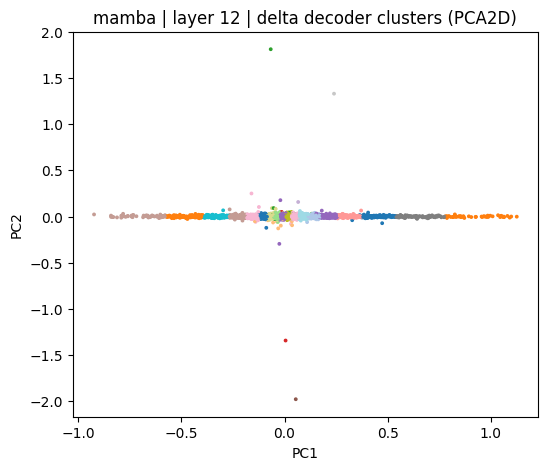

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


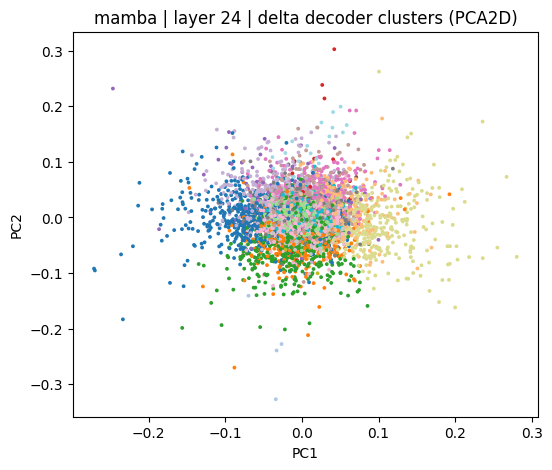

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


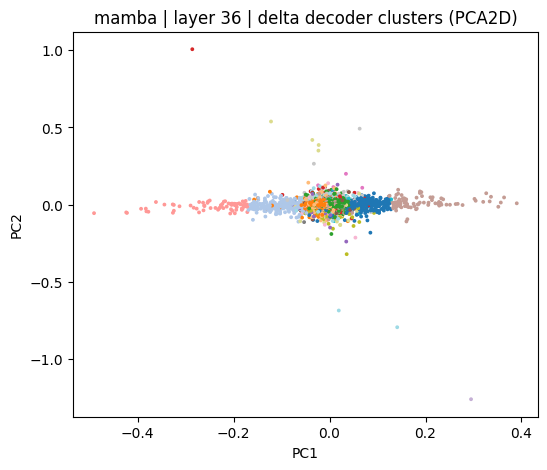

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


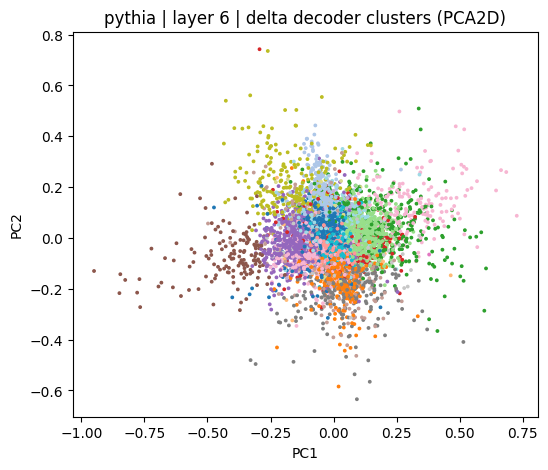

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


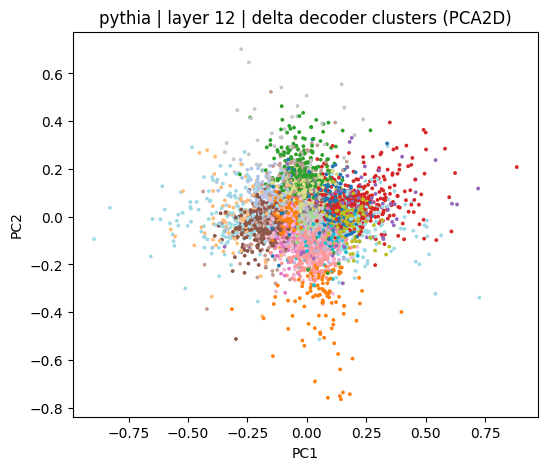

/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


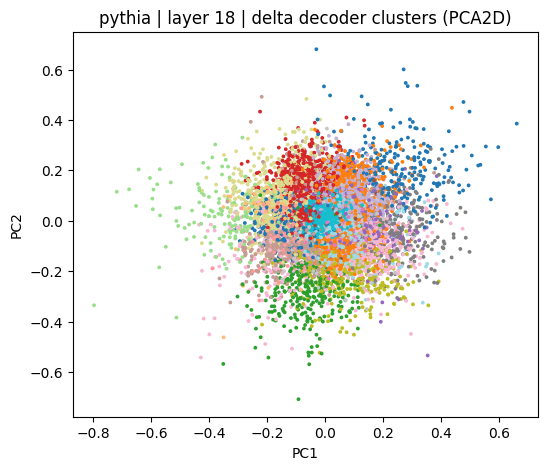

In [12]:

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def cluster_decoder(model_key, layer, signal, n_components=50, n_clusters=20):
    W = decoder_matrix(model_key, layer, signal).numpy()   # [F, d]
    X = W - W.mean(0, keepdims=True)
    Xp = PCA(n_components=n_components, random_state=0).fit_transform(X)
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=0).fit(Xp)
    return Xp, km.labels_

for model_key in MODELS:
    if 'delta' not in MODELS[model_key]['signals']:
        continue
    for layer in MODELS[model_key]['layers']:
        Xp, labels = cluster_decoder(model_key, layer, 'delta', n_components=50, n_clusters=30)
        plt.figure(figsize=(6,5))
        plt.scatter(Xp[:,0], Xp[:,1], c=labels, s=3, cmap='tab20')
        plt.title(f'{model_key} | layer {layer} | delta decoder clusters (PCA2D)')
        plt.xlabel('PC1'); plt.ylabel('PC2')
        plt.show()


### 5c. Model-to-model feature matching (state / delta)
- 同一層・同 signal で Mamba vs Pythia の decoder 最近傍 cos を集計


In [13]:

def match_models(layer, signal, top_k=10):
    W_m = decoder_matrix('mamba', layer, signal)
    W_t = decoder_matrix('pythia', layer, signal)
    Wm = W_m / W_m.norm(dim=1, keepdim=True)
    Wt = W_t / W_t.norm(dim=1, keepdim=True)
    sims = Wm @ Wt.T                       # [Fm, Ft]
    max_m = sims.max(dim=1)                # mamba -> pythia
    max_t = sims.max(dim=0)                # pythia -> mamba
    top_pairs = torch.topk(sims.view(-1), top_k).indices
    Fm, Ft = sims.shape
    print(f'== layer {layer} | signal {signal} ==')
    print('mamba->pythia mean max cos:', float(max_m.values.mean()))
    print('pythia->mamba mean max cos:', float(max_t.values.mean()))
    for idx in top_pairs.tolist():
        i = idx // Ft; j = idx % Ft
        print(f'  mamba {i:4d} <-> pythia {j:4d} | cos={float(sims[i,j]):.3f}')

for signal in ['state','delta']:
    # 共通の層だけ
    shared_layers = sorted(set(MODELS['mamba']['layers']) & set(MODELS['pythia']['layers']))
    for layer in shared_layers:
        match_models(layer, signal, top_k=10)


/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


== layer 12 | signal state ==
mamba->pythia mean max cos: 0.09056805819272995
pythia->mamba mean max cos: 0.07650158554315567
  mamba 10080 <-> pythia 13527 | cos=0.129
  mamba 4151 <-> pythia 13527 | cos=0.123
  mamba 15425 <-> pythia 4097 | cos=0.120
  mamba 3487 <-> pythia 11556 | cos=0.120
  mamba 8158 <-> pythia 2748 | cos=0.120
  mamba 1211 <-> pythia 2748 | cos=0.120
  mamba 6405 <-> pythia 2748 | cos=0.120
  mamba 2570 <-> pythia 5377 | cos=0.119
  mamba 6679 <-> pythia 3972 | cos=0.119
  mamba 15720 <-> pythia 9496 | cos=0.118
== layer 12 | signal delta ==
mamba->pythia mean max cos: 0.08760903775691986
pythia->mamba mean max cos: 0.08698152750730515
  mamba 12514 <-> pythia 6376 | cos=0.134
  mamba 13450 <-> pythia 8205 | cos=0.132
  mamba 10964 <-> pythia 13074 | cos=0.127
  mamba 8521 <-> pythia 15007 | cos=0.124
  mamba 11879 <-> pythia   31 | cos=0.121
  mamba 14861 <-> pythia 11142 | cos=0.121
  mamba 12029 <-> pythia 11438 | cos=0.121
  mamba 8346 <-> pythia 11957 | cos

### 5d. Cross-layer delta alignment (same model)
- delta 辞書の層間類似 (layer L -> L+1 の最近傍 cos 平均)


In [14]:

def cross_layer_alignment(model_key, signal, layer_src, layer_tgt):
    W_src = decoder_matrix(model_key, layer_src, signal)
    W_tgt = decoder_matrix(model_key, layer_tgt, signal)
    Ws = W_src / W_src.norm(dim=1, keepdim=True)
    Wt = W_tgt / W_tgt.norm(dim=1, keepdim=True)
    sims = Ws @ Wt.T
    max_src = sims.max(dim=1).values
    max_tgt = sims.max(dim=0).values
    return float(max_src.mean()), float(max_tgt.mean())

for model_key in MODELS:
    if 'delta' not in MODELS[model_key]['signals']:
        continue
    layers = MODELS[model_key]['layers']
    for i in range(len(layers)-1):
        l1, l2 = layers[i], layers[i+1]
        m1, m2 = cross_layer_alignment(model_key, 'delta', l1, l2)
        print(f'{model_key} delta {l1}->{l2}: src->tgt {m1:.3f}, tgt->src {m2:.3f}')


/tmp/ipykernel_45974/3544576655.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location or device)


mamba delta 12->24: src->tgt 0.103, tgt->src 0.101
mamba delta 24->36: src->tgt 0.105, tgt->src 0.106
pythia delta 6->12: src->tgt 0.129, tgt->src 0.125
pythia delta 12->18: src->tgt 0.128, tgt->src 0.131


## 6b. Hyperparam sweep aggregation (hidden_factor, k_frac, l1)
- checkpoint から hyperparam を取得し、train_log 最終値と合わせて DataFrame 化
- heatmap で hidden_factor × k_frac の指標を可視化（実データが複数ある場合）

In [ ]:

import seaborn as sns

def collect_runs(model_key, signal):
    rows = []
    cfg = MODELS[model_key]
    for layer in cfg['layers']:
        root = paths(model_key, layer, signal)
        ckpt_path = root/'sae_checkpoint.pt'
        log_path = root/'train_log.jsonl'
        if not (ckpt_path.exists() and log_path.exists()):
            continue
        ckpt = torch.load(ckpt_path, map_location='cpu')
        with open(log_path) as f:
            logs = [json.loads(line) for line in f]
        if len(logs)==0:
            continue
        last = logs[-1]
        hidden_factor = ckpt.get('hidden_factor') or ckpt['hidden_dim']/ckpt['input_dim']
        rows.append({
            'model': model_key,
            'layer': layer,
            'signal': signal,
            'hidden_factor': float(hidden_factor),
            'k_frac': float(ckpt.get('k_frac', 0.0)),
            'l1_lambda': float(ckpt.get('l1_lambda') or 0.0),
            'recon_loss': last.get('recon_loss'),
            'loss': last.get('loss'),
            'global_sparsity': last.get('global_sparsity'),
        })
    return pd.DataFrame(rows)

df_sweep = pd.concat([
    collect_runs('mamba','state'),
    collect_runs('mamba','delta'),
    collect_runs('pythia','state'),
    collect_runs('pythia','delta'),
], ignore_index=True)
print('sweep entries:', len(df_sweep))
display(df_sweep.head())

# heatmap example (recon_loss) if multiple settings exist
if len(df_sweep) > 0:
    for (model_key, signal, layer), sub in df_sweep.groupby(['model','signal','layer']):
        if sub['hidden_factor'].nunique()>1 and sub['k_frac'].nunique()>1:
            pivot = sub.pivot_table(index='hidden_factor', columns='k_frac', values='recon_loss')
            plt.figure(figsize=(6,4))
            sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
            plt.title(f'{model_key} | {signal} | layer {layer} | recon_loss')
            plt.show()


### 5e. Cross-layer alignment (state & delta)
- 同一モデル内で層間の decoder 類似度 (state/delta 両方)

In [ ]:

for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        layers = MODELS[model_key]['layers']
        for i in range(len(layers)-1):
            l1, l2 = layers[i], layers[i+1]
            m1, m2 = cross_layer_alignment(model_key, signal, l1, l2)
            print(f'{model_key} {signal} {l1}->{l2}: src->tgt {m1:.3f}, tgt->src {m2:.3f}')


### 4b. Delta firing vs reconstruction error correlation
- サンプル単位で active feature 数と再構成誤差の相関を計算

In [ ]:

import numpy as np

def recon_sparsity_corr(model_key, layer, signal, max_chunks=1, max_samples=5000):
    sae, _ = load_sae(model_key, layer, signal)
    errs = []; ks = []
    taken = 0
    for _, _, x in iter_chunks(model_key, layer, signal, max_chunks=max_chunks):
        x = x.to(device)
        with torch.no_grad():
            x_hat, z = sae(x)
        err = ((x - x_hat)**2).sum(dim=1).sqrt().cpu()
        k = (z!=0).sum(dim=1).cpu()
        errs.append(err); ks.append(k)
        taken += x.shape[0]
        if taken >= max_samples:
            break
    err = torch.cat(errs)[:max_samples].numpy()
    k = torch.cat(ks)[:max_samples].numpy()
    if len(err)==0:
        return None
    corr = np.corrcoef(k, err)[0,1]
    return corr, k, err

for model_key in MODELS:
    for signal in MODELS[model_key]['signals']:
        for layer in MODELS[model_key]['layers']:
            res = recon_sparsity_corr(model_key, layer, signal, max_chunks=1, max_samples=4000)
            if res is None:
                continue
            corr, k, err = res
            print(f'{model_key} | {signal} | layer {layer}: corr(k, reconL2) = {corr:.3f}')
